# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2


## Definiciones de modelos

In [18]:
model_cnn1 = keras.Sequential([

    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dense(10, activation='softmax')

])

model_cnn2 = keras.Sequential([

    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(256, activation='relu'),

    keras.layers.Dropout(0.5),

    keras.layers.Dense(10, activation='softmax')

])

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)


base_model.trainable = False

model_transfer = keras.Sequential([

    base_model,

    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(10, activation='softmax')

])



C:\Users\PC1\AppData\Local\Temp\ipykernel_19032\2011297977.py:40: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


## Entrenamiento de modelos.

In [19]:
model_cnn1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_transfer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [20]:
history_cnn1 = model_cnn1.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

history_cnn2 = model_cnn2.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

history_transfer = model_transfer.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4641 - loss: 1.4795 - val_accuracy: 0.5695 - val_loss: 1.2285
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6036 - loss: 1.1230 - val_accuracy: 0.5913 - val_loss: 1.1438
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6593 - loss: 0.9722 - val_accuracy: 0.6431 - val_loss: 1.0278
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6975 - loss: 0.8696 - val_accuracy: 0.6727 - val_loss: 0.9457
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7277 - loss: 0.7822 - val_accuracy: 0.6815 - val_loss: 0.9390
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7512 - loss: 0.7102 - val_accuracy: 0.6823 - val_loss: 0.9584
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7773 - loss: 0.6374 - val_accuracy: 0.6918 - val_loss: 0.9097
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8005 - loss: 0.5701 - 

## Estadística y gráficos

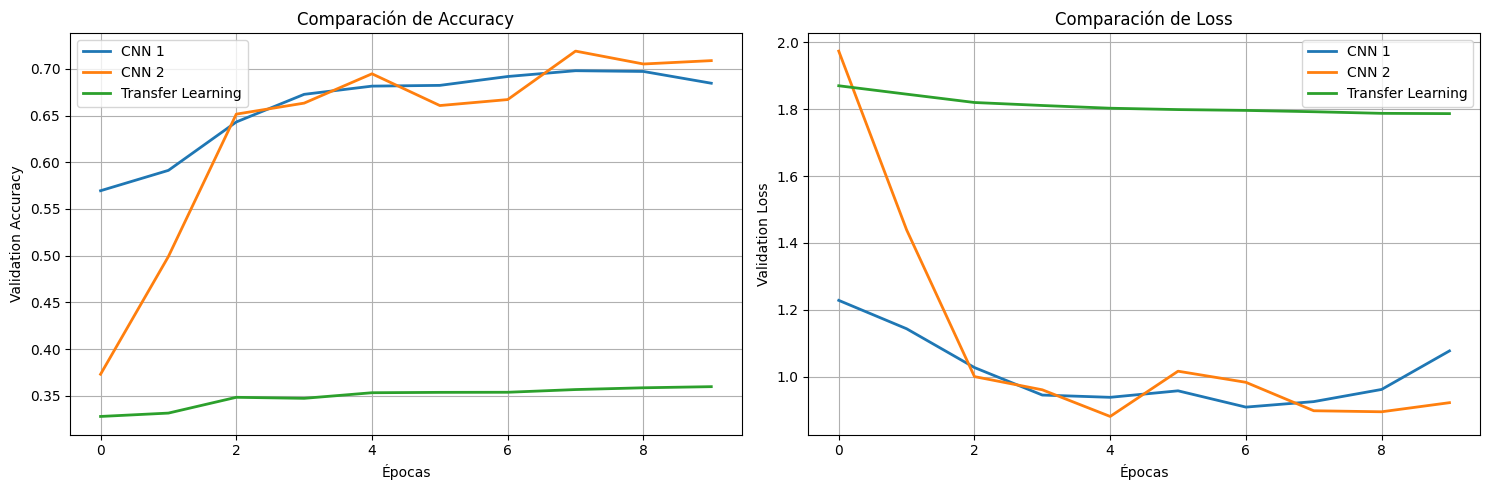

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

# =========================
# ACCURACY
# =========================

ax1.plot(
    history_cnn1.history['val_accuracy'],
    label='CNN 1',
    linewidth=2
)

ax1.plot(
    history_cnn2.history['val_accuracy'],
    label='CNN 2',
    linewidth=2
)

ax1.plot(
    history_transfer.history['val_accuracy'],
    label='Transfer Learning',
    linewidth=2
)

ax1.set_title('Comparación de Accuracy')

ax1.set_xlabel('Épocas')

ax1.set_ylabel('Validation Accuracy')

ax1.legend()

ax1.grid(True)


# =========================
# LOSS
# =========================

ax2.plot(
    history_cnn1.history['val_loss'],
    label='CNN 1',
    linewidth=2
)

ax2.plot(
    history_cnn2.history['val_loss'],
    label='CNN 2',
    linewidth=2
)

ax2.plot(
    history_transfer.history['val_loss'],
    label='Transfer Learning',
    linewidth=2
)

ax2.set_title('Comparación de Loss')

ax2.set_xlabel('Épocas')

ax2.set_ylabel('Validation Loss')

ax2.legend()

ax2.grid(True)

plt.tight_layout()

plt.show()

# Conclusiones.

Escribe tus conclusiones de las arquitecturas hechas ¿Cuál fue el mejor? ¿Por qué? ¿Qué mejoraría? ¿Cómo lo mejoraría?

Las arquitecturas implementadas permitieron comparar distintos niveles de complejidad en redes convolucionales. La CNN simple logró aprender patrones básicos, mientras que la segunda CNN obtuvo mejores resultados gracias al uso de más capas, Batch Normalization y Dropout, mejorando la estabilidad y reduciendo parcialmente el sobreajuste.

El mejor modelo fue el de Transfer Learning con MobileNetV2, ya que alcanzó mayor precisión y mejor capacidad de generalización utilizando conocimiento previamente aprendido en ImageNet. Como mejoras futuras, agregaría más técnicas de data augmentation, ajustaría hiperparámetros y aplicaría fine tuning para optimizar aún más el rendimiento del modelo.